# VANTA Dataset Builder

Goal:
- Collect movie metadata
- Build our own movie database
- Keep the dataset updated

In [3]:
from IPython.display import display
import pandas as pd
import requests
import time
from pathlib import Path

In [2]:
chunk_size = 100000

for chunk in pd.read_csv(
    "../../data/raw/title.basics.tsv",
    sep="\t",
    chunksize=chunk_size,
    low_memory=False
):
    display(chunk.head())
    break

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [3]:
chunk_size = 100000

output_file = "../../data/interim/movies_only.csv"

first_chunk = True

for chunk in pd.read_csv(
    "../../data/raw/title.basics.tsv",
    sep="\t",
    chunksize=chunk_size,
    low_memory=False
):

    movies = chunk[chunk["titleType"] == "movie"]

    movies.to_csv(
        output_file,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print("Movies dataset created successfully!")

Movies dataset created successfully!


In [4]:
movies_df = pd.read_csv(
    "../../data/interim/movies_only.csv",
    low_memory=False
)

movies_df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894,\N,45,Romance
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,\N,100,"Documentary,News,Sport"
2,tt0000502,movie,Bohemios,Bohemios,0,1905,\N,100,\N
3,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,\N,70,"Action,Adventure,Biography"
4,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907,\N,90,Drama


In [5]:
movies_df.shape

(753438, 9)

In [6]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753438 entries, 0 to 753437
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   tconst          753438 non-null  object
 1   titleType       753438 non-null  object
 2   primaryTitle    753435 non-null  object
 3   originalTitle   753435 non-null  object
 4   isAdult         753438 non-null  int64 
 5   startYear       753438 non-null  object
 6   endYear         753438 non-null  object
 7   runtimeMinutes  753438 non-null  object
 8   genres          753438 non-null  object
dtypes: int64(1), object(8)
memory usage: 51.7+ MB


In [7]:
movies_df["endYear"].unique()

array(['\\N'], dtype=object)

In [8]:
movies_df["isAdult"].value_counts()

isAdult
0    744376
1      9062
Name: count, dtype: int64

In [9]:
movies_df = movies_df.drop(columns=["titleType", "endYear"])

In [10]:
movies_df.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres
0,tt0000009,Miss Jerry,Miss Jerry,0,1894,45,Romance
1,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,100,"Documentary,News,Sport"
2,tt0000502,Bohemios,Bohemios,0,1905,100,\N
3,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,70,"Action,Adventure,Biography"
4,tt0000591,The Prodigal Son,L'enfant prodigue,0,1907,90,Drama


In [11]:
import os

OUTPUT_PATH = "../../data/processed/movies_enriched.csv"

if os.path.exists(OUTPUT_PATH):
    print("✅ Found existing enriched dataset. Resuming...")
    movies_df = pd.read_csv(OUTPUT_PATH)
else:
    print("🆕 Starting fresh enrichment...")
    movies_df = pd.read_csv("../../data/interim/movies.csv")

✅ Found existing enriched dataset. Resuming...


In [12]:
ratings_df = pd.read_csv(
    "../../data/raw/title.ratings.tsv",
    sep="\t",
    low_memory=False
)

In [13]:
ratings_df.head()

,tconst,averageRating,numVotes
0,tt0000001,5.7,2220
1,tt0000002,5.4,321
2,tt0000003,6.4,2365
3,tt0000004,5.1,197
4,tt0000005,6.2,3075


In [14]:
ratings_df.shape

(1702719, 3)

In [15]:
ratings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1702719 entries, 0 to 1702718
Data columns (total 3 columns):
 #   Column         Dtype  
---  ------         -----  
 0   tconst         object 
 1   averageRating  float64
 2   numVotes       int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 39.0+ MB


In [16]:
movies_df = movies_df.merge(ratings_df,on="tconst",how="left")

In [17]:
movies_df[["averageRating", "numVotes"]].isnull().sum()

KeyError: "None of [Index(['averageRating', 'numVotes'], dtype='object')] are in the [columns]"

In [ ]:
movies_df[movies_df["averageRating"].isnull()].head(20)

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers,castName,poster_path,backdrop_path,overview,tmdb_id,popularity,vote_average,vote_count,release_date


In [ ]:
movies_df[movies_df["averageRating"].isnull()]["startYear"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: startYear, dtype: float64

In [ ]:
movies_df[movies_df["averageRating"].isnull()]["startYear"].value_counts().sort_index().tail(20)

Series([], Name: count, dtype: int64)

In [ ]:
movies_df[movies_df["startYear"] == "\\N"].shape

(0, 20)

In [ ]:
movies_df = movies_df[movies_df["startYear"] != "\\N"]

In [ ]:
movies_df["startYear"].unique()[:10]

array([1897, 1906, 1912, 1911, 1919, 1913, 1915, 1914, 1917, 1916])

In [ ]:
movies_df[movies_df["genres"] == "\\N"].shape

(0, 22)

In [ ]:
movies_df = movies_df[movies_df["genres"] != "\\N"]

In [ ]:
movies_df["genres"].unique()[:10]

array(['Documentary,News,Sport', 'Action,Adventure,Biography',
       'Drama,History', 'Adventure,Drama,Fantasy', 'Biography,Drama',
       'Biography,Drama,Romance', 'Drama', 'Crime,Drama',
       'Crime,Drama,Mystery', 'Drama,Fantasy,Horror'], dtype=object)

In [ ]:
movies_df[["averageRating", "numVotes"]].isnull().sum()

averageRating    0
numVotes         0
dtype: int64

In [ ]:
movies_df = movies_df.dropna(
    subset=["averageRating", "numVotes"]
)

In [ ]:
movies_df[["averageRating", "numVotes"]].isnull().sum()

averageRating    0
numVotes         0
dtype: int64

In [ ]:
movies_df.shape

(337087, 9)

In [ ]:
movies_df["runtimeMinutes"].value_counts().head()

runtimeMinutes
\N     30365
90     19921
95      9309
85      9281
100     8849
Name: count, dtype: int64

In [ ]:
(movies_df["runtimeMinutes"] == "\\N").sum()

np.int64(0)

In [ ]:
movies_df["runtimeMinutes"] = movies_df["runtimeMinutes"].replace("\\N", pd.NA)

In [ ]:
movies_df["runtimeMinutes"] = pd.to_numeric(
    movies_df["runtimeMinutes"],
    errors="coerce"
)

In [ ]:
(movies_df["startYear"] == "\\N").sum()

np.int64(0)

In [ ]:
movies_df["startYear"] = movies_df["startYear"].astype(int)

In [ ]:
movies_df["tconst"].duplicated().sum()

np.int64(0)

In [ ]:
movies_df.dtypes

tconst             object
primaryTitle       object
originalTitle      object
isAdult             int64
startYear           int64
runtimeMinutes    float64
genres             object
averageRating     float64
numVotes          float64
dtype: object

In [ ]:
movies_df["numVotes"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

0.25       21.00
0.50       69.00
0.75      345.00
0.90     1927.00
0.95     6139.80
0.99    76593.96
Name: numVotes, dtype: float64

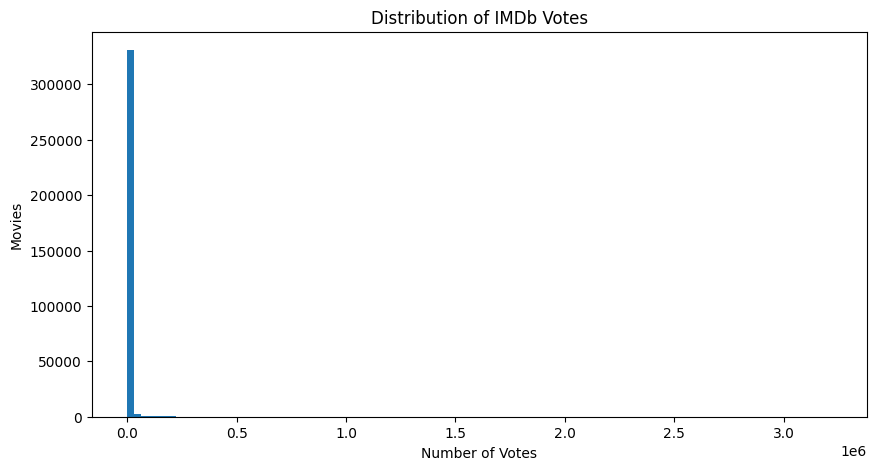

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(movies_df["numVotes"], bins=100)
plt.title("Distribution of IMDb Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Movies")
plt.show()

In [ ]:
thresholds = [10, 50, 100, 500, 1000, 5000, 10000]

for t in thresholds:
    count = (movies_df["numVotes"] >= t).sum()
    print(f"{t:>5} votes : {count:,} movies")

   10 votes : 317,244 movies
   50 votes : 190,221 movies
  100 votes : 145,733 movies
  500 votes : 70,241 movies
 1000 votes : 48,771 movies
 5000 votes : 18,965 movies
10000 votes : 12,507 movies


In [ ]:
movies_df = movies_df[movies_df["numVotes"] >= 500]

In [ ]:
movies_df.shape

(70241, 9)

In [ ]:
crew_df = pd.read_csv(
    "../../data/raw/title.crew.tsv",
    sep="\t",
    low_memory=False
)

In [ ]:
crew_df.head()

,tconst,directors,writers
0,tt0000001,nm0005690,\N
1,tt0000002,nm0721526,\N
2,tt0000003,nm0721526,nm0721526
3,tt0000004,nm0721526,\N
4,tt0000005,nm0005690,\N


In [ ]:
crew_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12696106 entries, 0 to 12696105
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   tconst     object
 1   directors  object
 2   writers    object
dtypes: object(3)
memory usage: 290.6+ MB


In [ ]:
crew_df.shape

(12696106, 3)

In [ ]:
crew_df.isnull().sum()

tconst       0
directors    0
writers      0
dtype: int64

In [ ]:
(crew_df["writers"] == "\\N").sum()

np.int64(6262691)

In [ ]:
(crew_df["directors"] == "\\N").sum()

np.int64(5629749)

In [ ]:
movies_df = movies_df.merge(
    crew_df,
    on="tconst",
    how="left"
)

In [ ]:
movies_df.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers
0,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,100.0,"Documentary,News,Sport",5.3,608.0,nm0714557,\N
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,70.0,"Action,Adventure,Biography",6.0,1083.0,nm0846879,nm0846879
2,tt0002101,Cleopatra,Cleopatra,0,1912,100.0,"Drama,History",5.1,668.0,nm0309130,"nm0765026,nm0309130"
3,tt0002130,Dante's Inferno,L'inferno,0,1911,71.0,"Adventure,Drama,Fantasy",7.1,4209.0,"nm0078205,nm0655824,nm0209738",nm0019604
4,tt0002199,From the Manger to the Cross,From the Manger to the Cross,0,1912,71.0,"Biography,Drama",5.9,714.0,nm0646058,nm0310155


In [ ]:
movies_df[["directors", "writers"]].isnull().sum()

directors    0
writers      0
dtype: int64

In [ ]:
(movies_df["writers"]=="\\N").sum()

np.int64(2181)

In [ ]:
(movies_df["directors"]=="\\N").sum()

np.int64(39)

In [ ]:
movies_df["directors"] = movies_df["directors"].replace("\\N", "")
movies_df["writers"] = movies_df["writers"].replace("\\N", "")

In [ ]:
names_df = pd.read_csv(
    "../../data/raw/name.basics.tsv",
    sep="\t",
    low_memory=False
)

In [ ]:
names_df.head()

,nconst,primaryName,birthYear,deathYear,primaryProfession,knownForTitles
0,nm0000001,Fred Astaire,1899,1987,"actor,miscellaneous,producer","tt0072308,tt0050419,tt0025164,tt0027125"
1,nm0000002,Lauren Bacall,1924,2014,"actress,miscellaneous,soundtrack","tt0037382,tt0075213,tt0038355,tt0117057"
2,nm0000003,Brigitte Bardot,1934,2025,"actress,music_department,producer","tt0057345,tt0049189,tt0056404,tt0054452"
3,nm0000004,John Belushi,1949,1982,"actor,writer,music_department","tt0072562,tt0077975,tt0080455,tt0078723"
4,nm0000005,Ingmar Bergman,1918,2007,"writer,director,actor","tt0050986,tt0083922,tt0069467,tt0050976"


In [ ]:
names_df = names_df[
    ["nconst", "primaryName"]
]

In [ ]:
names_df.shape

(15548570, 2)

In [ ]:
names_df.isnull().sum()

nconst          0
primaryName    11
dtype: int64

In [ ]:
(names_df["primaryName"] == "\\N").sum()

np.int64(89)

In [ ]:
(names_df["nconst"] == "\\N").sum()

np.int64(0)

In [ ]:
name_lookup = dict(
    zip(names_df["nconst"], names_df["primaryName"])
)

In [ ]:
movies_df["directors"].head()

0                        nm0714557
1                        nm0846879
2                        nm0309130
3    nm0078205,nm0655824,nm0209738
4                        nm0646058
Name: directors, dtype: object

In [ ]:
name_lookup["nm0714557"]

'Enoch J. Rector'

In [ ]:
movies_df["writers"].head()

0                       
1              nm0846879
2    nm0765026,nm0309130
3              nm0019604
4              nm0310155
Name: writers, dtype: object

In [ ]:
name_lookup["nm0846879"]

'Charles Tait'

In [ ]:
def convert_ids_to_names(id_string):
    
    if id_string == "":
        return ""

    ids = id_string.split(",")

    names = []

    for person_id in ids:
        names.append(
            name_lookup.get(person_id, person_id)
        )

    return ", ".join(names)

In [ ]:
convert_ids_to_names(
    movies_df["directors"].iloc[0]
)

'Enoch J. Rector'

In [ ]:
movies_df[
    movies_df["directors"].str.contains(",", regex=False)
].head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers
3,tt0002130,Dante's Inferno,L'inferno,0,1911,71.0,"Adventure,Drama,Fantasy",7.1,4209.0,"nm0078205,nm0655824,nm0209738",nm0019604
12,tt0003419,The Student of Prague,Der Student von Prag,0,1913,83.0,"Drama,Fantasy,Horror",6.4,2734.0,"nm0263912,nm0753233","nm0263912,nm0210503"
15,tt0003637,Assunta Spina,Assunta Spina,0,1915,72.0,Drama,6.2,534.0,"nm0078116,nm0784988","nm0223865,nm0078116,nm0784988"
22,tt0004026,The Golem,Der Golem,0,1914,60.0,Horror,6.7,1339.0,"nm0917467,nm0301961","nm0917467,nm0301961"
29,tt0004465,The Perils of Pauline,The Perils of Pauline,0,1914,199.0,"Action,Adventure,Drama",6.2,1121.0,"nm0309163,nm0533289","nm0323766,nm0225458,nm0782707,nm0589616"


In [ ]:
convert_ids_to_names(
    movies_df["directors"].iloc[3]
)

'Francesco Bertolini, Adolfo Padovan, Giuseppe de Liguoro'

In [ ]:
movies_df[
    movies_df["writers"].str.contains(",", regex=False)
].head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers
2,tt0002101,Cleopatra,Cleopatra,0,1912,100.0,"Drama,History",5.1,668.0,nm0309130,"nm0765026,nm0309130"
5,tt0002423,Passion,Madame DuBarry,0,1919,113.0,"Biography,Drama,Romance",6.7,1137.0,nm0523932,"nm0266183,nm0473134"
6,tt0002445,Quo Vadis?,Quo Vadis?,0,1913,120.0,"Drama,History",6.1,552.0,nm0345500,"nm0797197,nm0345500"
7,tt0002646,Atlantis,Atlantis,0,1913,121.0,Drama,6.5,536.0,nm0088881,"nm1834296,nm0369458,nm2421815"
8,tt0002844,Fantômas: In the Shadow of the Guillotine,Fantômas I: À l'ombre de la guillotine,0,1913,54.0,"Crime,Drama",6.9,2745.0,nm0275421,"nm0019855,nm0275421,nm0816232"


In [ ]:
convert_ids_to_names(
    movies_df["writers"].iloc[2]
)

'Victorien Sardou, Charles L. Gaskill'

In [ ]:
movies_df["directors"] = movies_df["directors"].apply(convert_ids_to_names)
movies_df["writers"] = movies_df["writers"].apply(convert_ids_to_names)

In [ ]:
movies_df.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers
0,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,100.0,"Documentary,News,Sport",5.3,608.0,Enoch J. Rector,
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,70.0,"Action,Adventure,Biography",6.0,1083.0,Charles Tait,Charles Tait
2,tt0002101,Cleopatra,Cleopatra,0,1912,100.0,"Drama,History",5.1,668.0,Charles L. Gaskill,"Victorien Sardou, Charles L. Gaskill"
3,tt0002130,Dante's Inferno,L'inferno,0,1911,71.0,"Adventure,Drama,Fantasy",7.1,4209.0,"Francesco Bertolini, Adolfo Padovan, Giuseppe ...",Dante Alighieri
4,tt0002199,From the Manger to the Cross,From the Manger to the Cross,0,1912,71.0,"Biography,Drama",5.9,714.0,Sidney Olcott,Gene Gauntier


In [ ]:
chunks = []

movie_ids = set(movies_df["tconst"])

for chunk in pd.read_csv(
    "../../data/raw/title.principals.tsv",
    sep="\t",
    chunksize=500000,
    low_memory=False
):
    chunk = chunk[chunk["tconst"].isin(movie_ids)]
    chunks.append(chunk)

principals_df = pd.concat(chunks, ignore_index=True)

In [ ]:
principals_df.shape

(1366852, 6)

In [ ]:
principals_df.head()

,tconst,ordering,nconst,category,job,characters
0,tt0000147,1,nm0179163,self,\N,"[""Self""]"
1,tt0000147,2,nm0280615,self,\N,"[""Self""]"
2,tt0000147,3,nm4082222,self,\N,"[""Self - Sullivan's Manager""]"
3,tt0000147,4,nm4081458,self,\N,"[""Self - Referee""]"
4,tt0000147,5,nm2256592,self,\N,"[""Self - Master of Ceremonies""]"


In [ ]:
principals_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1366852 entries, 0 to 1366851
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   tconst      1366852 non-null  object
 1   ordering    1366852 non-null  int64 
 2   nconst      1366852 non-null  object
 3   category    1366852 non-null  object
 4   job         1366852 non-null  object
 5   characters  1366852 non-null  object
dtypes: int64(1), object(5)
memory usage: 62.6+ MB


In [ ]:
principals_df["category"].unique()

array(['self', 'director', 'producer', 'cinematographer', 'actress',
       'actor', 'writer', 'composer', 'production_designer', 'editor',
       'casting_director', 'archive_footage', 'archive_sound'],
      dtype=object)

In [ ]:
(principals_df["category"]=="\\N").sum()

np.int64(0)

In [ ]:
(principals_df["nconst"]=="\\N").sum()


np.int64(0)

In [ ]:
cast_df = principals_df[
    principals_df["category"].isin(["actor", "actress"])
].copy()

In [ ]:
cast_df.shape

(664892, 6)

In [ ]:
cast_df.head()

,tconst,ordering,nconst,category,job,characters
8,tt0000574,1,nm0846887,actress,\N,"[""Kate Kelly""]"
9,tt0000574,2,nm0846894,actor,\N,"[""School Master""]"
10,tt0000574,3,nm1431224,actor,\N,"[""Joe Byrne""]"
11,tt0000574,4,nm3002376,actor,\N,"[""Steve Hart""]"
12,tt0000574,5,nm0143899,actor,\N,"[""Ned Kelly""]"


In [ ]:
cast_df["category"].value_counts()

category
actor      433356
actress    231536
Name: count, dtype: int64

In [ ]:
cast_df["castName"] = cast_df["nconst"].map(name_lookup)

In [ ]:
cast_df[["nconst", "castName"]].head(10)

,nconst,castName
8,nm0846887,Elizabeth Tait
9,nm0846894,John Tait
10,nm1431224,Nicholas Brierley
11,nm3002376,Norman Campbell
12,nm0143899,Godfrey Cass
13,nm0170118,Bella Cola
14,nm3001683,Will Coyne
15,nm0187697,Sam Crewes
16,nm3002754,Jack Ennis
17,nm3003322,John Forde


In [ ]:
cast_df["castName"].isnull().sum()

np.int64(15)

In [ ]:
cast_df = cast_df.drop(columns=["ordering", "job", "characters"])

In [ ]:
cast_grouped = (
    cast_df.groupby("tconst")["castName"]
    .apply(lambda x: ", ".join(x.dropna().unique()))
    .reset_index()
)

In [ ]:
cast_grouped.head()

,tconst,castName
0,tt0000574,"Elizabeth Tait, John Tait, Nicholas Brierley, ..."
1,tt0002101,"Helen Gardner, Pearl Sindelar, Miss Fielding, ..."
2,tt0002130,"Salvatore Papa, Arturo Pirovano, Giuseppe de L..."
3,tt0002199,"R. Henderson Bland, Percy Dyer, Gene Gauntier,..."
4,tt0002423,"Pola Negri, Emil Jannings, Harry Liedtke, Edua..."


In [ ]:
movies_df = movies_df.merge(
    cast_grouped,
    on="tconst",
    how="left"
)

In [ ]:
movies_df.head()

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers,castName
0,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,100.0,"Documentary,News,Sport",5.3,608.0,Enoch J. Rector,,NaN
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,70.0,"Action,Adventure,Biography",6.0,1083.0,Charles Tait,Charles Tait,"Elizabeth Tait, John Tait, Nicholas Brierley, ..."
2,tt0002101,Cleopatra,Cleopatra,0,1912,100.0,"Drama,History",5.1,668.0,Charles L. Gaskill,"Victorien Sardou, Charles L. Gaskill","Helen Gardner, Pearl Sindelar, Miss Fielding, ..."
3,tt0002130,Dante's Inferno,L'inferno,0,1911,71.0,"Adventure,Drama,Fantasy",7.1,4209.0,"Francesco Bertolini, Adolfo Padovan, Giuseppe ...",Dante Alighieri,"Salvatore Papa, Arturo Pirovano, Giuseppe de L..."
4,tt0002199,From the Manger to the Cross,From the Manger to the Cross,0,1912,71.0,"Biography,Drama",5.9,714.0,Sidney Olcott,Gene Gauntier,"R. Henderson Bland, Percy Dyer, Gene Gauntier,..."


In [ ]:
movies_df.shape

(70241, 12)

In [ ]:
movies_df.isnull().sum()

tconst               0
primaryTitle         0
originalTitle        0
isAdult              0
startYear            0
runtimeMinutes     228
genres               0
averageRating        0
numVotes             0
directors            0
writers              0
castName          3043
dtype: int64

In [ ]:
movies_df["castName"] = movies_df["castName"].fillna("")

In [ ]:
movies_df["runtimeMinutes"] = movies_df["runtimeMinutes"].fillna(0)

In [ ]:
import os

from dotenv import load_dotenv
from tqdm import tqdm

In [ ]:
load_dotenv()
TMDB_API_KEY = os.getenv("TMDB_API_KEY")

In [ ]:
def search_tmdb_movie(title, year):
    
    url = "https://api.themoviedb.org/3/search/movie"

    params = {
        "api_key": TMDB_API_KEY,
        "query": title,
        "year": int(year) if pd.notna(year) else None
    }

    try:
        response = requests.get(
            url,
            params=params,
            timeout=10
        )

        response.raise_for_status()

        data = response.json()

        if data["results"]:
            return data["results"][0]

        return None

    except requests.exceptions.RequestException as e:
        print("Request Error:", e)
        return None

In [ ]:
movie = search_tmdb_movie("Interstellar", 2014)
movie

{'adult': False,
 'backdrop_path': '/5XNQBqnBwPA9yT0jZ0p3s8bbLh0.jpg',
 'genre_ids': [12, 18, 878],
 'id': 157336,
 'title': 'Interstellar',
 'original_language': 'en',
 'original_title': 'Interstellar',
 'overview': 'The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.',
 'popularity': 71.334,
 'poster_path': '/yQvGrMoipbRoddT0ZR8tPoR7NfX.jpg',
 'release_date': '2014-11-05',
 'softcore': False,
 'video': False,
 'vote_average': 8.484,
 'vote_count': 40623}

In [ ]:
SAVE_EVERY = 500

OUTPUT_PATH = "../../data/processed/movies_enriched.csv"

In [ ]:
movies_df["poster_path"] = ""
movies_df["backdrop_path"] = ""
movies_df["overview"] = ""
movies_df["tmdb_id"] = None
movies_df["popularity"] = 0.0
movies_df["vote_average"] = 0.0
movies_df["vote_count"] = 0
movies_df["release_date"] = ""

In [ ]:
# for index, row in tqdm(
#     movies_df.iterrows(),
#     total=len(movies_df),
#     desc="Enriching Movies"
# ):


#     if pd.notna(row["tmdb_id"]):
#             continue 

#     title = row["primaryTitle"]
#     year = row["startYear"]

#     movie = search_tmdb_movie(title, year)

#     if movie:
#         movies_df.at[index, "tmdb_id"] = movie["id"]
#         movies_df.at[index, "overview"] = movie["overview"]
#         movies_df.at[index, "poster_path"] = movie["poster_path"]
#         movies_df.at[index, "backdrop_path"] = movie["backdrop_path"]
#         movies_df.at[index, "popularity"] = movie["popularity"]
#         movies_df.at[index, "vote_average"] = movie["vote_average"]
#         movies_df.at[index, "vote_count"] = movie["vote_count"]
#         movies_df.at[index, "release_date"] = movie["release_date"]  

#     if (index + 1) % SAVE_EVERY == 0:
#         movies_df.to_csv(OUTPUT_PATH, index=False)
#         print(f"✅ Saved after {index + 1} movies")

# movies_df.to_csv(OUTPUT_PATH, index=False)
# print("🎉 Final dataset saved!")      

Enriching Movies:   9%|▊         | 6000/70241 [01:05<33:12, 32.24it/s] 

✅ Saved after 6000 movies


Enriching Movies:  43%|████▎     | 30000/70241 [21:10<14:44:19,  1.32s/it]

✅ Saved after 30000 movies


Enriching Movies:  43%|████▎     | 30500/70241 [29:31<24:48:05,  2.25s/it]

...

✅ Saved after 69500 movies


Enriching Movies: 100%|█████████▉| 70000/70241 [6:12:15<04:39,  1.16s/it]

✅ Saved after 70000 movies


Enriching Movies: 100%|██████████| 70241/70241 [6:15:38<00:00,  3.12it/s]


🎉 Final dataset saved!


In [ ]:
movies_df.shape

(70241, 20)

In [6]:
movies_df

,tconst,primaryTitle,originalTitle,isAdult,startYear,runtimeMinutes,genres,averageRating,numVotes,directors,writers,castName,poster_path,backdrop_path,overview,tmdb_id,popularity,vote_average,vote_count,release_date
0,tt0000147,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897,100.0,"Documentary,News,Sport",5.3,608.0,Enoch J. Rector,NaN,NaN,/nL7aYlGYJZU7Gx8kFu9bTp3QYRu.jpg,/c3tjT6kFk3OJLyAtT2dtms6koRw.jpg,"This legendary fight was filmed on March 17, 1...",147610.0,0.4630,5.300,27,1897-05-22
1,tt0000574,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906,70.0,"Action,Adventure,Biography",6.0,1083.0,Charles Tait,Charles Tait,"Elizabeth Tait, John Tait, Nicholas Brierley, ...",/yjpsmvhel7zOY1Ov7Ebl7RlbjEy.jpg,/6vI31TbqaSLXNVVZhm1WGrATijZ.jpg,Just as Galeen and Wegener's Der Golem (1915) ...,20105.0,1.0149,5.233,43,1906-12-26
2,tt0002101,Cleopatra,Cleopatra,0,1912,100.0,"Drama,History",5.1,668.0,Charles L. Gaskill,"Victorien Sardou, Charles L. Gaskill","Helen Gardner, Pearl Sindelar, Miss Fielding, ...",/9Mi6Fiy68c3JIF3wnnD99JS38zR.jpg,/lyn7yVfvMPEdLQF1qjnwhAQHQYf.jpg,The fabled queen of Egypt's affair with Roman ...,71266.0,1.1218,3.432,22,1912-11-13
3,tt0002130,Dante's Inferno,L'inferno,0,1911,71.0,"Adventure,Drama,Fantasy",7.1,4209.0,"Francesco Bertolini, Adolfo Padovan, Giuseppe ...",Dante Alighieri,"Salvatore Papa, Arturo Pirovano, Giuseppe de L...",/ky0z9hDlajlwL3fBqwsCSbjJGjR.jpg,/jEk1QNc9fBnbboh9t3nooPoIxBm.jpg,The classic tale of Dante's journey through he...,70512.0,3.8243,6.600,161,1911-03-01
4,tt0002199,From the Manger to the Cross,From the Manger to the Cross,0,1912,71.0,"Biography,Drama",5.9,714.0,Sidney Olcott,Gene Gauntier,"R. Henderson Bland, Percy Dyer, Gene Gauntier,...",/wsRp6nRPam7F7ShyhRtswBRE283.jpg,/qcbHWpr2VnyiwxJPRTcv09WdJdu.jpg,The life of Jesus is played out in tableaux sh...,119876.0,0.6513,5.100,24,1912-10-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70236,tt9907782,The Cursed,Eight for Silver,0,2021,111.0,"Fantasy,Horror,Mystery",6.2,23126.0,Sean Ellis,Sean Ellis,"Boyd Holbrook, Kelly Reilly, Alistair Petrie, ...",/bewmBcjJxHeipS1PNu9Lfyvt3zY.jpg,/hPurpFeAkvkvWYRVSDYGDaDSgva.jpg,"In the late 19th century, a brutal land baron ...",630392.0,5.0695,6.562,436,2021-07-28
70237,tt9908390,Le lion,Le lion,0,2020,95.0,Comedy,5.5,1659.0,Ludovic Colbeau-Justin,"Alexandre Coquelle, Matthieu Le Naour","Dany Boon, Philippe Katerine, Anne Serra, Samu...",/zfLuACsPcwH6aonTKukn96d1qpp.jpg,/fpX67PBBlozc2UOf2LBB5IiQHT8.jpg,A psychiatric hospital patient pretends to be ...,589970.0,1.6932,5.400,226,2020-01-29
70238,tt9911196,The Marriage Escape,De beentjes van Sint-Hildegard,0,2020,103.0,"Comedy,Drama",7.4,3585.0,Johan Nijenhuis,"Radek Bajgar, Herman Finkers, Maarten Lebens, ...","Herman Finkers, Johanna ter Steege, Leonie ter...",/qZNlF6i3MOvwhRV8SDfp5M40hVx.jpg,/knQXUmeoXYxkuAlM3G4TphtqzPo.jpg,Jan has been married to Gedda for 35 years. Ge...,591915.0,0.8133,7.500,52,2020-02-10
70239,tt9916270,Il talento del calabrone,Il talento del calabrone,0,2020,84.0,Thriller,5.9,1555.0,Giacomo Cimini,"Giacomo Cimini, Lorenzo Collalti, Alessandro R...","Sergio Castellitto, Lorenzo Richelmy, Anna Fog...",/5pAAjVDpq4cCCsZsdivkCLMY6Hm.jpg,/w3eAsDs1HXWsz4GgcICR8rR4Mdm.jpg,"Dj Steph is a young radio deejay on the rise, ...",670203.0,0.7275,6.403,445,2020-11-18


In [ ]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70241 entries, 0 to 70240
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tconst          70241 non-null  object 
 1   primaryTitle    70241 non-null  object 
 2   originalTitle   70241 non-null  object 
 3   isAdult         70241 non-null  int64  
 4   startYear       70241 non-null  int64  
 5   runtimeMinutes  70241 non-null  float64
 6   genres          70241 non-null  object 
 7   averageRating   70241 non-null  float64
 8   numVotes        70241 non-null  float64
 9   directors       70241 non-null  object 
 10  writers         70241 non-null  object 
 11  castName        70241 non-null  object 
 12  poster_path     70031 non-null  object 
 13  backdrop_path   67009 non-null  object 
 14  overview        70241 non-null  object 
 15  tmdb_id         67689 non-null  object 
 16  popularity      70241 non-null  float64
 17  vote_average    70241 non-null 

In [ ]:
movies_df = pd.read_csv("../../data/processed/movies_enriched.csv")

In [31]:
movies_df.shape

(70241, 20)

In [ ]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70241 entries, 0 to 70240
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   tconst          70241 non-null  object 
 1   primaryTitle    70241 non-null  object 
 2   originalTitle   70241 non-null  object 
 3   isAdult         70241 non-null  int64  
 4   startYear       70241 non-null  int64  
 5   runtimeMinutes  70241 non-null  float64
 6   genres          70241 non-null  object 
 7   averageRating   70241 non-null  float64
 8   numVotes        70241 non-null  float64
 9   directors       70202 non-null  object 
 10  writers         68060 non-null  object 
 11  castName        67198 non-null  object 
 12  poster_path     67479 non-null  object 
 13  backdrop_path   64457 non-null  object 
 14  overview        67552 non-null  object 
 15  tmdb_id         67689 non-null  float64
 16  popularity      70241 non-null  float64
 17  vote_average    70241 non-null 

In [7]:
movies_df.isnull().sum()

tconst               0
primaryTitle         0
originalTitle        0
isAdult              0
startYear            0
runtimeMinutes       0
genres               0
averageRating        0
numVotes             0
directors           39
writers           2181
castName          3043
poster_path       2762
backdrop_path     5784
overview          2689
tmdb_id           2552
popularity           0
vote_average         0
vote_count           0
release_date      2554
dtype: int64

In [32]:
movies_df["overview"] = movies_df["overview"].fillna("")
movies_df["castName"] = movies_df["castName"].fillna("")
movies_df["writers"] = movies_df["writers"].fillna("")
movies_df["directors"] = movies_df["directors"].fillna("")
movies_df["poster_path"] = movies_df["poster_path"].fillna("")
movies_df["backdrop_path"] = movies_df["backdrop_path"].fillna("")
movies_df["release_date"] = movies_df["release_date"].fillna("")
movies_df["tmdb_id"] = movies_df["tmdb_id"].fillna(0)

In [33]:
movies_df.isnull().sum()

tconst            0
primaryTitle      0
originalTitle     0
isAdult           0
startYear         0
runtimeMinutes    0
genres            0
averageRating     0
numVotes          0
directors         0
writers           0
castName          0
poster_path       0
backdrop_path     0
overview          0
tmdb_id           0
popularity        0
vote_average      0
vote_count        0
release_date      0
dtype: int64

In [34]:
def remove_space(text):
    return " ".join([word.replace(" ", "") for word in text.split(", ")])

In [35]:
movies_df["directors"] = movies_df["directors"].apply(remove_space)
movies_df["writers"] = movies_df["writers"].apply(remove_space)
movies_df["castName"] = movies_df["castName"].apply(remove_space)

In [36]:
movies_df["genres"] = movies_df["genres"].str.replace(",", " ")

In [37]:
movies_df["tags"] = (
    movies_df["genres"] + " " +
    movies_df["directors"] + " " +
    movies_df["writers"] + " " +
    movies_df["castName"] + " " +
    movies_df["overview"]
)

In [38]:
movies_df["tags"] = movies_df["tags"].str.lower()

In [39]:
movies_df["tags"][0]

"documentary news sport enochj.rector   this legendary fight was filmed on march 17, 1897, using 63mm film that produced an aspect ratio of about 1.75:1. using three adjacent cameras, enoch rector recorded the entire fight, simultaneously creating the world's first known feature film, as the resulting footage lasted over 90 minutes in length. about a quarter of the film survives today."

In [40]:
import re

movies_df["tags"] = movies_df["tags"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x)
)

In [41]:
movies_df["tags"] = movies_df["tags"].apply(
    lambda x: " ".join(x.split())
)

In [42]:
movies_df[["primaryTitle", "tags"]].head()

,primaryTitle,tags
0,The Corbett-Fitzsimmons Fight,documentary news sport enochjrector this legen...
1,The Story of the Kelly Gang,action adventure biography charlestait charles...
2,Cleopatra,drama history charleslgaskill victoriensardou ...
3,Dante's Inferno,adventure drama fantasy francescobertolini ado...
4,From the Manger to the Cross,biography drama sidneyolcott genegauntier rhen...


In [43]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sarth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [44]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [45]:
def remove_stopwords(text):

    words = text.split()

    cleaned_words = []

    for word in words:

        if word not in stop_words:
            cleaned_words.append(word)

    return " ".join(cleaned_words)


movies_df["tags"] = movies_df["tags"].apply(remove_stopwords)

In [46]:
movies_df[["primaryTitle", "tags"]].head()

,primaryTitle,tags
0,The Corbett-Fitzsimmons Fight,documentary news sport enochjrector legendary ...
1,The Story of the Kelly Gang,action adventure biography charlestait charles...
2,Cleopatra,drama history charleslgaskill victoriensardou ...
3,Dante's Inferno,adventure drama fantasy francescobertolini ado...
4,From the Manger to the Cross,biography drama sidneyolcott genegauntier rhen...


In [47]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [48]:
def stem_text(text):
    words = text.split()

    stemmed_words = []

    for word in words:
        stemmed_words.append(stemmer.stem(word))

    return " ".join(stemmed_words)


movies_df["tags"] = movies_df["tags"].apply(stem_text)

In [49]:
movies_df[["primaryTitle", "tags"]].head()

,primaryTitle,tags
0,The Corbett-Fitzsimmons Fight,documentari news sport enochjrector legendari ...
1,The Story of the Kelly Gang,action adventur biographi charlestait charlest...
2,Cleopatra,drama histori charleslgaskil victoriensard cha...
3,Dante's Inferno,adventur drama fantasi francescobertolini adol...
4,From the Manger to the Cross,biographi drama sidneyolcott genegaunti rhende...


In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [51]:
tfidf = TfidfVectorizer(
    max_features=5000
)

In [52]:
tfidf_matrix = tfidf.fit_transform(movies_df["tags"])

In [53]:
tfidf_matrix.shape

(70241, 5000)

In [93]:
import scipy.sparse as sp

sp.save_npz(
    "../../data/processed/tfidf_matrix.npz",
    tfidf_matrix
)

In [54]:
from sklearn.metrics.pairwise import cosine_similarity

In [55]:
def recommend_movies(movie_title, n=10):
    # Find the movie
    matches = movies_df[
        movies_df["primaryTitle"].str.lower() == movie_title.lower()
    ]

    if matches.empty:
        return f"Movie '{movie_title}' not found."

    # Get the index of the movie
    movie_index = matches.index[0]

    # Calculate similarity with all movies
    similarities = cosine_similarity(
        tfidf_matrix[movie_index],
        tfidf_matrix
    ).flatten()

    # Get indices of most similar movies
    similar_indices = similarities.argsort()[::-1][1:n+1]

    # Return movie titles
    return movies_df.iloc[similar_indices][
        ["primaryTitle", "startYear"]
    ].reset_index(drop=True)

In [63]:
movie_index = movies_df[
    movies_df["primaryTitle"].str.lower() == "interstellar"
].index[0]

similarities = cosine_similarity(
    tfidf_matrix[movie_index],
    tfidf_matrix
).flatten()

top_indices = similarities.argsort()[::-1][1:11]

movies_df.loc[
    top_indices,
    ["primaryTitle", "startYear"]
].assign(
    similarity=similarities[top_indices]
)

,primaryTitle,startYear,similarity
9660,The Mysterious Island of Captain Nemo,1973,0.274237
54603,Domm: Until the Last Breath,2026,0.246829
61915,Mango Dreams,2016,0.246829
41925,Tunka Tunka,2021,0.246829
3168,Queen of the Amazons,1946,0.245334
61509,Asian Treasure,2020,0.245334
65719,An Elephant's Journey,2017,0.245334
20785,Kara Murat: Seyh Gaffar'a Karsi,1977,0.245334
52818,Anantha,2023,0.245334
42486,MGS: Philanthropy,2009,0.242338


In [64]:
movies_df.loc[
    [9660, 54603, 61915, 41925, 3168],
    ["primaryTitle", "tags"]
]

,primaryTitle,tags
9660,The Mysterious Island of Captain Nemo,adventur scifi juanantoniobardem henricolpi ja...
54603,Domm: Until the Last Breath,adventur drama redoanroni alaminhasannirjhar m...
61915,Mango Dreams,adventur drama johnupchurch mazahirrahim hamza...
41925,Tunka Tunka,adventur drama garrykhatrao vinodkumar jdavin ...
3168,Queen of the Amazons,adventur edwardfinney rogermerton robertloweri...


In [65]:
movies_df.loc[
    movies_df["primaryTitle"].str.lower() == "interstellar",
    ["primaryTitle", "tags"]
]

,primaryTitle,tags
31735,Interstellar,adventur drama scifi christophernolan jonathan...


In [66]:
movie_index = movies_df[
    movies_df["primaryTitle"].str.lower() == "interstellar"
].index[0]

feature_names = tfidf.get_feature_names_out()

movie_vector = tfidf_matrix[movie_index].toarray().flatten()

top_features = movie_vector.argsort()[::-1][:20]

[(feature_names[i], movie_vector[i]) for i in top_features]

[('johnlithgow', np.float64(0.3115986209406407)),
 ('ellenburstyn', np.float64(0.30883020233155783)),
 ('voyag', np.float64(0.28313011560975665)),
 ('distanc', np.float64(0.2805050077978162)),
 ('vast', np.float64(0.27775328099494956)),
 ('conquer', np.float64(0.26908633666467474)),
 ('limit', np.float64(0.25123255200241146)),
 ('adventur', np.float64(0.24533442437452052)),
 ('newli', np.float64(0.24318546334679603)),
 ('space', np.float64(0.2295430734906929)),
 ('explor', np.float64(0.20021356554153333)),
 ('involv', np.float64(0.18447980433287473)),
 ('human', np.float64(0.18365016058521186)),
 ('travel', np.float64(0.17752995029990914)),
 ('use', np.float64(0.17185571671504266)),
 ('group', np.float64(0.1563795769471899)),
 ('scifi', np.float64(0.15592085916938836)),
 ('discov', np.float64(0.14896571711011863)),
 ('make', np.float64(0.1429167026965419)),
 ('drama', np.float64(0.06095406169000209))]

In [67]:
movies_df["weighted_tags"] = (
    movies_df["genres"].fillna("").str.replace(",", " ") + " " +
    movies_df["genres"].fillna("").str.replace(",", " ") + " " +
    movies_df["genres"].fillna("").str.replace(",", " ") + " " +
    
    movies_df["directors"].fillna("").str.replace(",", " ") + " " +
    movies_df["directors"].fillna("").str.replace(",", " ") + " " +
    movies_df["directors"].fillna("").str.replace(",", " ") + " " +
    movies_df["directors"].fillna("").str.replace(",", " ") + " " +
    
    movies_df["writers"].fillna("").str.replace(",", " ") + " " +
    movies_df["writers"].fillna("").str.replace(",", " ") + " " +
    movies_df["writers"].fillna("").str.replace(",", " ") + " " +
    
    movies_df["castName"].fillna("").str.replace(",", " ") + " " +
    movies_df["castName"].fillna("").str.replace(",", " ") + " " +
    
    movies_df["overview"].fillna("")
)

In [68]:
movies_df.loc[
    movies_df["primaryTitle"].str.lower() == "interstellar",
    ["primaryTitle", "weighted_tags"]
]

,primaryTitle,weighted_tags
31735,Interstellar,Adventure Drama Sci-Fi Adventure Drama Sci-Fi ...


In [69]:
weighted_tfidf = TfidfVectorizer(
    max_features=5000
)

weighted_tfidf_matrix = weighted_tfidf.fit_transform(
    movies_df["weighted_tags"]
)

In [70]:
weighted_tfidf_matrix.shape

(70241, 5000)

In [94]:
sp.save_npz(
    "../../data/processed/weighted_tfidf_matrix.npz",
    weighted_tfidf_matrix
)

In [71]:
def recommend_movies_weighted(movie_title, n=10):

    # Find the movie
    matches = movies_df[
        movies_df["primaryTitle"].str.lower() == movie_title.lower()
    ]

    if matches.empty:
        return f"Movie '{movie_title}' not found."

    # Get the index of the movie
    movie_index = matches.index[0]

    # Calculate similarity with all movies
    similarities = cosine_similarity(
        weighted_tfidf_matrix[movie_index],
        weighted_tfidf_matrix
    ).flatten()

    # Get indices of most similar movies
    similar_indices = similarities.argsort()[::-1][1:n+1]

    # Return movie titles
    return movies_df.loc[
        similar_indices,
        ["primaryTitle", "startYear"]
    ].reset_index(drop=True)

In [95]:
import joblib

joblib.dump(
    tfidf,
    "../../data/processed/tfidf_vectorizer.joblib"
)

joblib.dump(
    weighted_tfidf,
    "../../data/processed/weighted_tfidf_vectorizer.joblib"
)

['../../data/processed/weighted_tfidf_vectorizer.joblib']

In [72]:
recommend_movies_weighted("Interstellar")

,primaryTitle,startYear
0,The Mysterious Island of Captain Nemo,1973
1,MGS: Philanthropy,2009
2,Woken,2023
3,Mad Doctor of Blood Island,1968
4,Dead Sunrise,2017
5,Seat 25,2017
6,Alien Visitor,1996
7,Spider-Man: Lotus,2023
8,The Day Mars Invaded Earth,1962
9,InAlienable,2007


In [73]:
recommend_movies("Interstellar")

,primaryTitle,startYear
0,The Mysterious Island of Captain Nemo,1973
1,Domm: Until the Last Breath,2026
2,Mango Dreams,2016
3,Tunka Tunka,2021
4,Queen of the Amazons,1946
5,Asian Treasure,2020
6,An Elephant's Journey,2017
7,Kara Murat: Seyh Gaffar'a Karsi,1977
8,Anantha,2023
9,MGS: Philanthropy,2009


In [59]:
recommend_movies("Iron Man")

,primaryTitle,startYear
0,Iron Man 2,2010
1,Iron Man 3,2013
2,Star Wars: Threads of Destiny,2014
3,MGS: Philanthropy,2009
4,Nursie,2004
5,Avengers: Age of Ultron,2015
6,Dead Zone,2022
7,Clown,2014
8,The Mysterious Island of Captain Nemo,1973
9,Journey to the Center of the Earth,1988


In [74]:
recommend_movies_weighted("Iron Man")

,primaryTitle,startYear
0,Iron Man 3,2013
1,Iron Man 2,2010
2,Spider-Man: Homecoming,2017
3,X-Men: Apocalypse,2016
4,X-Men: Days of Future Past,2014
5,The Fantastic Four: First Steps,2025
6,Avengers: Age of Ultron,2015
7,Spider-Man: Far from Home,2019
8,Avengers: Endgame,2019
9,Thunderbolts*,2025


In [ ]:
recommend_movies("Avengers: Endgame")

,primaryTitle,startYear
0,Avengers: Infinity War,2018
1,Captain America: Civil War,2016
2,Avengers: Age of Ultron,2015
3,Trollhunters: Rise of the Titans,2021
4,Browncoats: Independence War,2015
5,Yuvarathnaa,2021
6,Star Wars: Threads of Destiny,2014
7,MGS: Philanthropy,2009
8,Vengeance of the Three Musketeers,1961
9,Scaramouche,1952


In [75]:
recommend_movies_weighted("Avengers: Endgame")

,primaryTitle,startYear
0,X-Men: Apocalypse,2016
1,Avengers: Infinity War,2018
2,Avengers: Age of Ultron,2015
3,X-Men: Days of Future Past,2014
4,Iron Man 3,2013
5,The Fantastic Four: First Steps,2025
6,Ant-Man,2015
7,Captain America: Civil War,2016
8,Black Panther: Wakanda Forever,2022
9,Thunderbolts*,2025


In [77]:
recommend_movies_weighted("Titanic")

,primaryTitle,startYear
0,Kazakh Khanate: Diamond Sword,2016
1,D-Day: Battle of Omaha Beach,2019
2,Midday Adventures,2017
3,Nobody Wanted to Die,1965
4,1921: Puzha Muthal Puzha Vare,2022
5,Iluminados por el fuego,2005
6,"Wackersdorf - Be Alert, Courageous and Solidaric",2018
7,The Fall of Abdulhamit,2003
8,Bandirma Missile Club,2022
9,Teacher Kemal,1981


In [78]:
recommend_movies("Titanic")

,primaryTitle,startYear
0,Titanic 666,2022
1,Titan: The OceanGate Disaster,2025
2,Titanic,1953
3,Titanic,1997
4,Teen Titans GO! To the Movies,2018
5,Death Ship,1980
6,Slingshot,2024
7,Raise the Titanic,1980
8,Betting on Zero,2016
9,Sink the Bismarck!,1960


In [79]:
recommend_movies_weighted("Inception")

,primaryTitle,startYear
0,The Mysterious Island of Captain Nemo,1973
1,5th Passenger,2017
2,Area Q.,2011
3,Maro Prapancham,2023
4,Incontrol,2017
5,MGS: Philanthropy,2009
6,Baida,2025
7,Woken,2023
8,Dead Sunrise,2017
9,Mad Doctor of Blood Island,1968


In [80]:
recommend_movies("Inception")

,primaryTitle,startYear
0,Cruel and Unusual,2001
1,Fight or Flight,2024
2,As Good as Dead,2022
3,Beyond the Rising Moon,1987
4,Kiss Kiss Bang Bang,2001
5,Mrs Undercover,2023
6,Rosso,1985
7,The Fifth Cord,1971
8,Cypher,2002
9,The Ghost,2008


In [81]:
movies_df.loc[
    movies_df["primaryTitle"].str.lower() == "inception",
    [
        "primaryTitle",
        "genres",
        "directors",
        "writers",
        "castName",
        "overview",
        "tags",
        "weighted_tags"
    ]
].T

,39725
primaryTitle,Inception
genres,Adventure Sci-Fi Thriller
directors,ChristopherNolan
writers,ChristopherNolan
castName,LeonardoDiCaprio JosephGordon-Levitt ElliotPag...
overview,"Cobb, a skilled thief who commits corporate es..."
tags,adventur scifi thriller christophernolan chris...
weighted_tags,Adventure Sci-Fi Thriller Adventure Sci-Fi Thr...


In [61]:
movies_df[movies_df["primaryTitle"].str.lower() == "interstellar"][
    ["primaryTitle", "genres", "directors", "writers", "castName", "overview", "tags"]
]

,primaryTitle,genres,directors,writers,castName,overview,tags
31735,Interstellar,Adventure Drama Sci-Fi,ChristopherNolan,JonathanNolan ChristopherNolan,MatthewMcConaughey AnneHathaway JessicaChastai...,The adventures of a group of explorers who mak...,adventur drama scifi christophernolan jonathan...


In [62]:
movies_df.loc[
    movies_df["primaryTitle"].str.lower() == "interstellar",
    "tags"
].iloc[0]

'adventur drama scifi christophernolan jonathannolan christophernolan matthewmcconaughey annehathaway jessicachastain mackenziefoy ellenburstyn johnlithgow timothechalamet davidoyelowo collettewolf francisxmccarthi adventur group explor make use newli discov wormhol surpass limit human space travel conquer vast distanc involv interstellar voyag'

In [82]:
recommend_movies("Twilight")

,primaryTitle,startYear
0,It Happened in Broad Daylight,1958
1,Stolen,2009
2,Sons of Adam,2018
3,Kuldip Patwal: I Didn't Do It!,2017
4,Fortune Defies Death,2018
5,Bommala Koluvu,2022
6,Ashes of Paradise,1997
7,The Deposition,2012
8,Turned Out,2018
9,Charlie Chan's Secret,1935


In [83]:
recommend_movies_weighted("Twilight")

,primaryTitle,startYear
0,It Happened in Broad Daylight,1958
1,Ashes of Paradise,1997
2,Turned Out,2018
3,The Deposition,2012
4,Bommala Koluvu,2022
5,Sons of Adam,2018
6,The Odds,2011
7,Toxic Skies,2008
8,Across the Furious Sea,2023
9,Dark Places,2015


In [84]:
from sentence_transformers import SentenceTransformer

In [85]:
semantic_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [86]:
text = """
Adventure Sci-Fi Thriller.
Christopher Nolan.
A team of explorers travel through a wormhole in space
in an attempt to ensure humanity's survival.
"""

embedding = semantic_model.encode(text)

embedding.shape

(384,)

In [87]:
movies_df["semantic_text"] = (
    movies_df["genres"].fillna("") + ". " +
    movies_df["directors"].fillna("") + ". " +
    movies_df["writers"].fillna("") + ". " +
    movies_df["castName"].fillna("") + ". " +
    movies_df["overview"].fillna("")
)

In [88]:
movies_df.loc[
    movies_df["primaryTitle"].str.lower() == "interstellar",
    ["primaryTitle", "semantic_text"]
]

,primaryTitle,semantic_text
31735,Interstellar,Adventure Drama Sci-Fi. ChristopherNolan. Jona...


In [89]:
semantic_embeddings = semantic_model.encode(
    movies_df["semantic_text"].tolist(),
    batch_size=64,
    show_progress_bar=True
)

Batches:   0%|          | 0/1098 [00:00<?, ?it/s]

In [90]:
semantic_embeddings.shape

(70241, 384)

In [92]:
import numpy as np

np.save(
    "../../data/processed/semantic_embeddings.npy",
    semantic_embeddings
)

In [96]:
movie_index = movies_df[
    movies_df["primaryTitle"].str.lower() == "interstellar"
].index[0]

print("INTERSTELLAR:")
print(movies_df.loc[movie_index, "tags"])

INTERSTELLAR:
adventur drama scifi christophernolan jonathannolan christophernolan matthewmcconaughey annehathaway jessicachastain mackenziefoy ellenburstyn johnlithgow timothechalamet davidoyelowo collettewolf francisxmccarthi adventur group explor make use newli discov wormhol surpass limit human space travel conquer vast distanc involv interstellar voyag


In [97]:
print("\nMGS: PHILANTHROPY:")

mgs_index = movies_df[
    movies_df["primaryTitle"].str.lower() == "mgs: philanthropy"
].index[0]

print(movies_df.loc[mgs_index, "tags"])


MGS: PHILANTHROPY:
action adventur scifi giacomotalamini paoloceccotti jonathanealam valentinapaggiarin giacomotalamini giacomotalamini phillipsacramento patrizialiccardi nicolacecconi luciendodg glenngoa andreafurlan williammartin adambehr giovannicontessotto
